Import packages

In [32]:
import numpy as np
import skfuzzy as fuzz
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

In [33]:
import pickle

Load in datasets

In [34]:
# path_to_customer_metrics = '../data/cleaned/halfyearmetrics/combined_halfyear_metrics.csv' 
path_to_customer_metrics = '../data/cleaned/customer_metrics_with_product_related_features.csv'  
customer_metrics = pd.read_csv(path_to_customer_metrics)
customer_metrics_save = customer_metrics.copy()

In [35]:
saved_features_path = "../data/features_with_weights.csv"

In [36]:
features_df = pd.read_csv(saved_features_path)

In [37]:
feature_columns = features_df['Feature'].to_list()
# Create dataframe with listed features
customer_metrics = customer_metrics[feature_columns]

In [38]:
weights = features_df['FinalWeight'].to_list()

List features that will be used to trian model

In [39]:
#remove customers if Profit is outside the range of -300k & 10 million
print(customer_metrics[(customer_metrics["TotalProfit"] < -300000) | (customer_metrics["TotalProfit"] > 3000000)])
customer_metrics = customer_metrics[(customer_metrics["TotalProfit"] > -300000) & (customer_metrics["TotalProfit"] < 3000000)]


      TotalProfit  PopularOrderRatio  TotalSalesQty  HighProfitOrderRatio  \
125  4.200976e+06               8930       96079455                   747   
734  5.131414e+06              12982      187257427                  1351   

     OrderCount  TotalUnitPrice  NumDistinctProducts  NumDistinctProductGroups  
125       11814    4.176623e+06                 1116                        43  
734        8237    3.877713e+05                 1593                        29  


In [40]:
# Apply a scaler
standardScaler = StandardScaler()
normalizedFeatures = standardScaler.fit_transform(customer_metrics)
print(normalizedFeatures[:5])

[[-0.06520945 -0.0798181  -0.11552671  0.02286596 -0.12511096 -0.10827965
   0.34850653  1.48385851]
 [-0.19961361 -0.13400261 -0.13994669 -0.20173859 -0.18519005 -0.18801449
  -0.27509613 -0.28952002]
 [-0.19897725 -0.13400261 -0.13943045 -0.20173859 -0.18519005 -0.19917355
  -0.23352262 -0.69876122]
 [-0.17787761 -0.13400261 -0.13994718 -0.07071927 -0.18232914  0.07046045
  -0.29588289 -0.69876122]
 [-0.19541511 -0.13400261 -0.13985995 -0.18302154 -0.18519005 -0.1987636
  -0.28548951 -0.56234749]]


In [41]:
weightedFeatures = normalizedFeatures * weights

Run fuzzy c-means model on the dataset using specified features with applied weights

In [42]:
#Preform fuzzy clustering
num_clusters = 6
fuzziness_parameter = 2

center, u, u0, distance, cost, partition_coeff, fuzz_partition_coeff = fuzz.cluster.cmeans(
    weightedFeatures.T, num_clusters, fuzziness_parameter, error=.005, maxiter=1000
)
# Compute hard cluster assignments
hard_labels = np.argmax(u, axis=0)

# We assume the first column of normalizedFeatures_base represents revenue.
# Compute a weighted average revenue for each cluster using the membership degrees.
avg_revenue = []
for i in range(num_clusters):
    # Get the membership values for cluster i
    membership = u[i, :]
    # Select the revenue values from normalizedFeatures_base (column 0)
    revenue = normalizedFeatures[:, 0]
    # Compute the weighted average revenue for cluster i
    # Note: if no point has membership in a cluster, use 0.
    if membership.sum() > 0:
        cluster_avg = np.average(revenue, weights=membership)
    else:
        cluster_avg = 0
    avg_revenue.append(cluster_avg)
avg_revenue = np.array(avg_revenue)

# Sort clusters by average revenue so that the lowest revenue cluster gets label 0,
# and the highest gets label (num_clusters-1)
order = np.argsort(avg_revenue)
mapping = np.empty_like(order)
mapping[order] = np.arange(num_clusters)

# Apply the mapping to convert original memberships to the new ordered labels
renumbered_labels = mapping[hard_labels]

print(renumbered_labels)
# Add the ClusterLabel column to the features list
cluster_names = {0: 'Rock', 1: 'Bronze', 2: 'Silver', 3: 'Gold', 4: 'Diamond', 5: 'Platinum'}
renumbered_labels = np.vectorize(cluster_names.get)(renumbered_labels)
customer_metrics.loc[:, 'ClusterLabel'] = renumbered_labels

#rename clusterlabel column to cluster
customer_metrics.rename(columns={'ClusterLabel': 'Cluster'}, inplace=True)

[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0
 0 5 0 0 0 1 0 2 2 0 0 0 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 2 0 0 3 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 5 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 3 0 0 2 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 1 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 2 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [43]:
# Save the model components
model_data = {
    'centers': center,
    'mapping': mapping,
    'cluster_names': cluster_names,
    'fuzziness_parameter': fuzziness_parameter,
    'num_clusters': num_clusters
}
# Save to a file
with open('../models/fuzzy_cmeans_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

In [44]:
# Formatting to display large numbers in a cleaner view
def format_millions(x, pos):
    return f'{x*1e-6:.1f}M'

Create graph to show clusters

In [45]:
# Define the custom palette in the same order as the cluster names
custom_palette = {
    0: "#1f77b4",  # Blue
    1: "#d62728",  # Red
    2: "#2ca02c",  # Green
    3: "#ff7f0e",  # Orange
    4: "#9467bd",  # Purple
    5: "#875839",  # Purple
}

# Set the palette
sns.set_palette(custom_palette.values())



# Plot the graph between Total Revenue and Total Profit for the clustering
"""
plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(data=customer_metrics, x='TotalRevenue', y='OrderCount', hue='Cluster', palette=custom_palette, s=100)
plt.title('Total Revenue vs Order Count (6 Clusters)')
plt.xlabel('Total Revenue')
plt.ylabel('Order Count')
# Create a custom legend to ensure the order of legend items
handles, labels = scatter.get_legend_handles_labels()
order = [list(cluster_names.keys()).index(int(label)) for label in labels if label.isdigit()]
plt.legend([handles[idx] for idx in order], [cluster_names[int(labels[idx])] for idx in order], title='Cluster')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()
"""

"\nplt.figure(figsize=(10, 6))\nscatter = sns.scatterplot(data=customer_metrics, x='TotalRevenue', y='OrderCount', hue='Cluster', palette=custom_palette, s=100)\nplt.title('Total Revenue vs Order Count (6 Clusters)')\nplt.xlabel('Total Revenue')\nplt.ylabel('Order Count')\n# Create a custom legend to ensure the order of legend items\nhandles, labels = scatter.get_legend_handles_labels()\norder = [list(cluster_names.keys()).index(int(label)) for label in labels if label.isdigit()]\nplt.legend([handles[idx] for idx in order], [cluster_names[int(labels[idx])] for idx in order], title='Cluster')\nplt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))\nplt.show()\n"

Find optimal number of clusters based on perormance metrics

In [46]:
# Extract the CustomerName column from the saved DataFrame
"""
customer_names = customer_metrics_save["CustomerName"]


# Insert it at position 0 of the customer_metrics DataFrame

customer_metrics.insert(0, "CustomerName", customer_names)

customer_metrics.to_csv("customer_metrics_output_new.csv", index=False)
"""

'\ncustomer_names = customer_metrics_save["CustomerName"]\n\n\n# Insert it at position 0 of the customer_metrics DataFrame\n\ncustomer_metrics.insert(0, "CustomerName", customer_names)\n\ncustomer_metrics.to_csv("customer_metrics_output_new.csv", index=False)\n'

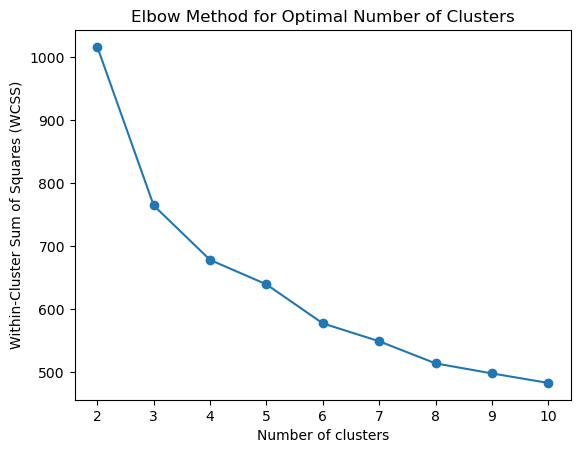

In [47]:
# Define the range for the number of clusters
cluster_range = range(2, 11)

# List to store the within-cluster sum of squares (WCSS) for each number of clusters
wcss = []

# Perform fuzzy c-means clustering for each number of clusters and calculate WCSS
for i in cluster_range:
    center, u, u0, distance, cost, partition_coeff, fuzz_partition_coeff = fuzz.cluster.cmeans(
        normalizedFeatures.T, i, fuzziness_parameter, error=.005, maxiter=1000
    )
    # Calculate WCSS as the sum of squared distances
    wcss.append(np.sum(np.min(distance, axis=0)))

# Plot the elbow method
plt.plot(cluster_range, wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

0.8320283003334049
0.9198054347514575
1786.1506496341665


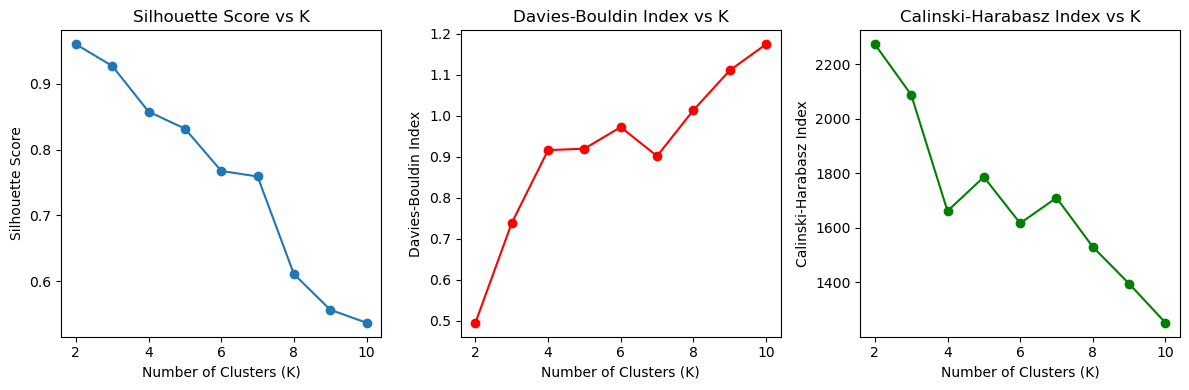

In [48]:
# Range of K values to try
K_range = range(2, 11)

# Lists to store the scores
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

# Find metrics for model performace with each number of clusters
for K in K_range:
    center, u, u0, distance, cost, partition_coeff, fuzz_partition_coeff = fuzz.cluster.cmeans(
        weightedFeatures.T, K, fuzziness_parameter, error=.005, maxiter=1000
    )
    clusters = np.argmax(u, axis=0)

    # Compute metrics
    silhouette_scores.append(silhouette_score(weightedFeatures, clusters))
    davies_bouldin_scores.append(davies_bouldin_score(weightedFeatures, clusters))
    calinski_harabasz_scores.append(calinski_harabasz_score(weightedFeatures, clusters))
    if K == 5:
        print(silhouette_score(weightedFeatures, clusters))
        print(davies_bouldin_score(weightedFeatures, clusters))
        print(calinski_harabasz_score(weightedFeatures, clusters))

# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')

plt.subplot(1, 3, 2)
plt.plot(K_range, davies_bouldin_scores, marker='o', color='r')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index vs K')

plt.subplot(1, 3, 3)
plt.plot(K_range, calinski_harabasz_scores, marker='o', color='g')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index vs K')

plt.tight_layout()
plt.show()

Optimal number of clusters was found to be 5, this number will be used for the model

In [49]:
#print 5 customers from each cluster
"""
for i in range(num_clusters):
    print(f"Cluster {i+1}")
    print(customer_metrics[customer_metrics['ClusterLabel'] == i].head())
"""

'\nfor i in range(num_clusters):\n    print(f"Cluster {i+1}")\n    print(customer_metrics[customer_metrics[\'ClusterLabel\'] == i].head())\n'